In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

This notebook performs exploratory data analysis on the LIAR dataset to understand structural, behavioral, and speaker-level patterns in political fact-checking outcomes. The goal is to identify signal sources that may support clustering and downstream modeling.

# Load Dataset and Add Columns

In [52]:
cols = [
    "id",
    "label",
    "statement",
    "subject",
    "speaker",
    "speaker_job",
    "state",
    "party",
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "context"
]

In [53]:
df_1 = pd.read_csv("../data/raw/train.tsv", sep="\t", names=cols)
df_1.shape

(10240, 14)

In [54]:
df_2 = pd.read_csv("../data/raw/valid.tsv", sep="\t", names=cols)
df_2.shape

(1284, 14)

In [55]:
df_3 = pd.read_csv("../data/raw/test.tsv", sep="\t", names=cols)
df_3.shape

(1267, 14)

In [56]:
df = pd.concat([df_1, df_2, df_3], ignore_index=True)
df.shape

(12791, 14)

# Dataset Inspection

In this section, I validate that the LIAR dataset loaded correctly and understand its basic structure before any cleaning or modeling. I inspect the dataset shape, column types, and missingness patterns to identify potential data quality issues that could affect downstream analysis.

In [57]:
df.head()

,id,label,statement,subject,speaker,speaker_job,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12791 entries, 0 to 12790
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    12791 non-null  object 
 1   label                 12791 non-null  object 
 2   statement             12791 non-null  object 
 3   subject               12789 non-null  object 
 4   speaker               12789 non-null  object 
 5   speaker_job           9223 non-null   object 
 6   state                 10040 non-null  object 
 7   party                 12789 non-null  object 
 8   barely_true_counts    12789 non-null  float64
 9   false_counts          12789 non-null  float64
 10  half_true_counts      12789 non-null  float64
 11  mostly_true_counts    12789 non-null  float64
 12  pants_on_fire_counts  12789 non-null  float64
 13  context               12660 non-null  object 
dtypes: float64(5), object(9)
memory usage: 1.4+ MB


In [59]:
df.describe()

,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts
count,12789.000000,12789.000000,12789.000000,12789.000000,12789.000000
mean,11.583939,13.359059,17.185785,16.497850,6.251388
std,18.978037,24.140086,35.847678,36.165276,16.180777
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,2.000000,3.000000,3.000000,1.000000
75%,12.000000,15.000000,13.000000,12.000000,5.000000
max,70.000000,114.000000,160.000000,163.000000,105.000000


In [60]:
df.sample(5)

,id,label,statement,subject,speaker,speaker_job,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
4193,29.json,true,Let's pay attention to kids who are not going ...,economy,hillary-clinton,Presidential candidate,New York,democrat,40.0,29.0,69.0,76.0,7.0,NaN
3256,1211.json,false,On a cap-and-trade plan.,"cap-and-trade,climate-change,environment",tim-pawlenty,NaN,NaN,republican,2.0,3.0,3.0,6.0,1.0,a letter to the Minnesota delegation in Washin...
9610,532.json,false,We must deal with the here and now and assure ...,energy,john-mccain,U.S. senator,Arizona,republican,31.0,39.0,31.0,37.0,8.0,"Houston, Texas"
10402,9722.json,pants-fire,President Barack Obamas latest executive order...,"ebola,public-health",blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,an article posted on Infowars.com
4805,6380.json,mostly-true,One out of every two kids who are graduating c...,"economy,message-machine-2012",republican-jewish-coalition,Advocacy group,"Washington, D.C.",republican,0.0,0.0,0.0,2.0,0.0,a campaign ad


In [24]:
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nUnique speakers:", df["speaker"].nunique())
print("Unique parties:", df["party"].nunique())
print("Unique states:", df["state"].nunique())


Missing values per column:
id                         0
label                      0
statement                  0
subject                    2
speaker                    2
speaker_job             3568
state                      0
party                      0
barely_true_counts         2
false_counts               2
half_true_counts           2
mostly_true_counts         2
pants_on_fire_counts       2
context                  131
state_clean                0
party_grouped              0
dtype: int64

Unique speakers: 3309
Unique parties: 25
Unique states: 66


# Minimal Data Cleaning

This section addresses inconsistencies in categorical metadata, particularly state names and party labels. The goal is to standardize values to reduce noise, prevent artificial category inflation, and ensure consistent downstream analysis.

## Clean State Names

In [61]:
df["state"].unique().tolist()

['Texas',
 'Virginia',
 'Illinois',
 nan,
 'Florida',
 'Wisconsin',
 'New Jersey',
 'Vermont',
 'Massachusetts',
 'Maryland',
 'Washington, D.C. ',
 'Oregon',
 'New York',
 'Washington, D.C.',
 'California',
 'Missouri',
 'Rhode Island',
 'West Virginia',
 'Arkansas',
 'New Hampshire',
 'Ohio',
 'Georgia',
 'Arizona',
 'Wyoming',
 'Delaware',
 'Kentucky',
 'Kansas',
 'ohio',
 'Colorado',
 'North Carolina',
 'New Mexico',
 'Illinois ',
 'Alaska',
 'South Carolina',
 'Minnesota',
 'Tennessee',
 'Pennsylvania',
 'Iowa',
 'Connecticut',
 'Louisiana',
 'Indiana',
 'Florida ',
 'Utah',
 'Michigan',
 'Oklahoma',
 'Nevada',
 'Oregon ',
 'Virgina',
 'Nebraska',
 'Georgia ',
 'Washington D.C.',
 'California ',
 'Massachusetts ',
 'Alabama',
 'Russia',
 'Washington state',
 'Washington',
 'District of Columbia',
 'Unknown',
 'Colorado ',
 'New Hampshire ',
 'Mississippi',
 'Rhode island',
 'China',
 'United Kingdom',
 'Virginia ',
 'South Dakota',
 'Qatar',
 'Montana',
 'North Dakota',
 'Idaho',


In [62]:
df["state"] = df["state"].astype(str).str.strip()

df["state"] = df["state"].str.title()

df["state"] = df["state"].replace({
    "Washington, D.C.": "District Of Columbia",
    "Washington D.C.": "District Of Columbia",
    "Washington Dc": "District Of Columbia",
    "Washington Dc.": "District Of Columbia",
    "Washington Dc ": "District Of Columbia"
})


In [63]:
df["state"].unique().tolist()

['Texas',
 'Virginia',
 'Illinois',
 'Nan',
 'Florida',
 'Wisconsin',
 'New Jersey',
 'Vermont',
 'Massachusetts',
 'Maryland',
 'District Of Columbia',
 'Oregon',
 'New York',
 'California',
 'Missouri',
 'Rhode Island',
 'West Virginia',
 'Arkansas',
 'New Hampshire',
 'Ohio',
 'Georgia',
 'Arizona',
 'Wyoming',
 'Delaware',
 'Kentucky',
 'Kansas',
 'Colorado',
 'North Carolina',
 'New Mexico',
 'Alaska',
 'South Carolina',
 'Minnesota',
 'Tennessee',
 'Pennsylvania',
 'Iowa',
 'Connecticut',
 'Louisiana',
 'Indiana',
 'Utah',
 'Michigan',
 'Oklahoma',
 'Nevada',
 'Virgina',
 'Nebraska',
 'Alabama',
 'Russia',
 'Washington State',
 'Washington',
 'Unknown',
 'Mississippi',
 'China',
 'United Kingdom',
 'South Dakota',
 'Qatar',
 'Montana',
 'North Dakota',
 'Idaho',
 'Maine',
 'Virginia Director, Coalition To Stop Gun Violence',
 'Virgiia',
 'Hawaii',
 'Atlanta',
 'Tennesse',
 'Pa - Pennsylvania',
 'Tex',
 'The United States']

In [64]:
US_STATES = {
    "Alabama","Alaska","Arizona","Arkansas","California","Colorado",
    "Connecticut","Delaware","Florida","Georgia","Hawaii","Idaho",
    "Illinois","Indiana","Iowa","Kansas","Kentucky","Louisiana",
    "Maine","Maryland","Massachusetts","Michigan","Minnesota",
    "Mississippi","Missouri","Montana","Nebraska","Nevada",
    "New Hampshire","New Jersey","New Mexico","New York",
    "North Carolina","North Dakota","Ohio","Oklahoma","Oregon",
    "Pennsylvania","Rhode Island","South Carolina","South Dakota",
    "Tennessee","Texas","Utah","Vermont","Virginia","Washington",
    "West Virginia","Wisconsin","Wyoming",
    "District Of Columbia"
}

STATE_CORRECTIONS = {
    "Virgina": "Virginia",
    "Virgiia": "Virginia",
    "Tennesse": "Tennessee",
    "Tex": "Texas",
    "Pa - Pennsylvania": "Pennsylvania",
    "Washington State": "Washington",
    "Washington": "Washington",
    "Nan": None,
    "Unknown": None,
    "Atlanta": None,
    "Russia": None,
    "China": None,
    "United Kingdom": None,
    "Qatar": None,
    "The United States": None,
    "Virginia Director, Coalition To Stop Gun Violence": None
}

In [65]:
def normalize_state(state):
    if pd.isna(state):
        return "Other"
    
    state = state.strip()

    if state in STATE_CORRECTIONS:
        corrected = STATE_CORRECTIONS[state]
        if corrected is None:
            return "Other"
        state = corrected

    state = state.title()
    

    if state in US_STATES:
        return state
    
    return "Other"

In [66]:
df["state_clean"] = df["state"].apply(normalize_state)

df["state_clean"].unique().tolist()

['Texas',
 'Virginia',
 'Illinois',
 'Other',
 'Florida',
 'Wisconsin',
 'New Jersey',
 'Vermont',
 'Massachusetts',
 'Maryland',
 'District Of Columbia',
 'Oregon',
 'New York',
 'California',
 'Missouri',
 'Rhode Island',
 'West Virginia',
 'Arkansas',
 'New Hampshire',
 'Ohio',
 'Georgia',
 'Arizona',
 'Wyoming',
 'Delaware',
 'Kentucky',
 'Kansas',
 'Colorado',
 'North Carolina',
 'New Mexico',
 'Alaska',
 'South Carolina',
 'Minnesota',
 'Tennessee',
 'Pennsylvania',
 'Iowa',
 'Connecticut',
 'Louisiana',
 'Indiana',
 'Utah',
 'Michigan',
 'Oklahoma',
 'Nevada',
 'Nebraska',
 'Alabama',
 'Washington',
 'Mississippi',
 'South Dakota',
 'Montana',
 'North Dakota',
 'Idaho',
 'Maine',
 'Hawaii']

The `state` field contains inconsistencies including typographical errors, international locations, and free-text descriptors. We standardized valid U.S. state names and grouped all non-U.S. or ambiguous entries into an "Other" category. This ensures categorical integrity and prevents spurious feature inflation.

## Test For State Name Cleanup

In [67]:
VALID_OUTPUTS = US_STATES.union({"Other"})

assert df["state_clean"].isna().sum() == 0, "Null values found in state_clean"

invalid_states = set(df["state_clean"].unique()) - VALID_OUTPUTS
assert len(invalid_states) == 0, f"Invalid states found: {invalid_states}"

assert "Virgina" not in df["state_clean"].values
assert "Virgiia" not in df["state_clean"].values
assert "Tennesse" not in df["state_clean"].values

print("All state_clean tests passed successfully.")

All state_clean tests passed successfully.


In [68]:
sorted(df["party"].astype(str).str.strip().unique())

['Moderate',
 'activist',
 'business-leader',
 'columnist',
 'constitution-party',
 'county-commissioner',
 'democrat',
 'democratic-farmer-labor',
 'education-official',
 'government-body',
 'green',
 'independent',
 'journalist',
 'labor-leader',
 'liberal-party-canada',
 'libertarian',
 'nan',
 'newsmaker',
 'none',
 'ocean-state-tea-party-action',
 'organization',
 'republican',
 'state-official',
 'talk-show-host',
 'tea-party-member']

## Clean Party Names

In [69]:
df["party"] = df["party"].fillna("unknown")
df["party"] = df["party"].astype(str).str.strip().str.lower()

In [70]:
def simplify_party(p):
    if p == "democrat" or p == "democratic-farmer-labor":
        return "democrat"
    elif p == "republican":
        return "republican"
    elif p in ["independent", "libertarian", "green", "constitution-party"]:
        return "third-party"
    elif p in ["none", "unknown", "nan"]:
        return "unknown"
    else:
        return "non-party-role"

df["party_grouped"] = df["party"].apply(simplify_party)

In [71]:
df["party_grouped"].value_counts(normalize=True)

party_grouped
republican        0.442890
democrat          0.323509
unknown           0.170667
non-party-role    0.044406
third-party       0.018529
Name: proportion, dtype: float64

The original `party` column contains heterogeneous entries including political parties, media roles, and organizations. To reduce noise and improve interpretability, I grouped parties into broader categories (democrat, republican, third-party, unknown, non-party-role). This transformation preserves meaningful political distinctions while preventing fragmentation due to minor or inconsistent labels.

## Test Clean Party Names

In [72]:
VALID_PARTY_GROUPS = {"democrat", "republican", "third-party", "unknown", "non-party-role"}

assert df["party_grouped"].isna().sum() == 0, "Null values found in party_grouped"

invalid_groups = set(df["party_grouped"].unique()) - VALID_PARTY_GROUPS
assert len(invalid_groups) == 0, f"Unexpected party_grouped values: {invalid_groups}"

assert simplify_party("democrat") == "democrat"
assert simplify_party("democratic-farmer-labor") == "democrat"
assert simplify_party("republican") == "republican"

assert simplify_party("independent") == "third-party"
assert simplify_party("libertarian") == "third-party"
assert simplify_party("green") == "third-party"
assert simplify_party("constitution-party") == "third-party"

assert simplify_party("none") == "unknown"
assert simplify_party("unknown") == "unknown"
assert simplify_party("nan") == "unknown"

assert simplify_party("journalist") == "non-party-role"
assert simplify_party("activist") == "non-party-role"
assert simplify_party("organization") == "non-party-role"
assert simplify_party("talk-show-host") == "non-party-role"

mismatch = (df["party_grouped"] != df["party"].apply(simplify_party)).sum()
assert mismatch == 0, f"Found {mismatch} mismatches between party_grouped and simplify_party output"

print("All party_grouped tests passed successfully.")

All party_grouped tests passed successfully.


# Observe Label Distribution

Before modeling, it is important to understand the distribution of truth labels to assess potential class imbalance and its implications for supervised learning.

In [73]:
print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nLabel proportions:")
print(df["label"].value_counts(normalize=True))



Label distribution:
label
half-true      2627
false          2507
mostly-true    2454
barely-true    2103
true           2053
pants-fire     1047
Name: count, dtype: int64

Label proportions:
label
half-true      0.205379
false          0.195997
mostly-true    0.191854
barely-true    0.164412
true           0.160503
pants-fire     0.081854
Name: proportion, dtype: float64


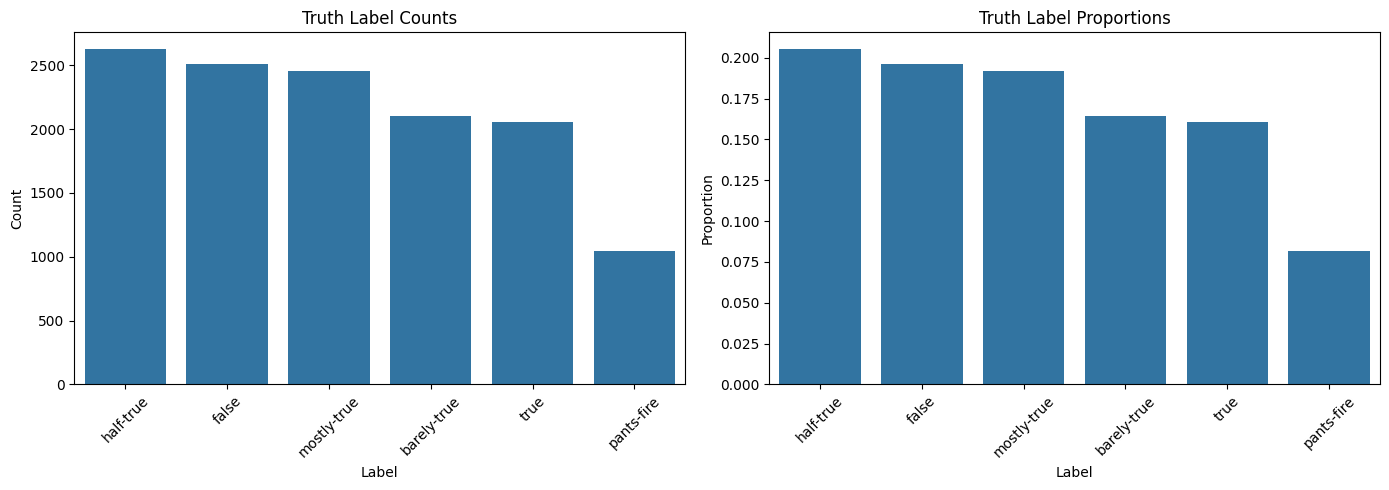

In [74]:
label_counts = df["label"].value_counts()
label_props = df["label"].value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    ax=axes[0]
)
axes[0].set_title("Truth Label Counts")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(
    x=label_props.index,
    y=label_props.values,
    ax=axes[1]
)
axes[1].set_title("Truth Label Proportions")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Proportion")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The dataset exhibits moderate class imbalance. The most frequent labels are half-true, false, and mostly-true, while pants-fire is the least common category. Although the imbalance is not extreme, it may affect classification performance, particularly for minority classes. Techniques such as class weighting or stratified splitting may be necessary during model training.

In [81]:
print(pd.crosstab(df["party_grouped"], df["label"]))

print("\nParty distribution:")
print(df["party_grouped"].value_counts())

print("\nParty vs label (row-normalized):")
print(pd.crosstab(df["party_grouped"], df["label"], normalize="index"))

label           barely-true  false  half-true  mostly-true  pants-fire  true
party_grouped                                                               
democrat                586    633        932          995         185   807
non-party-role           94    119        127           99          39    90
republican             1061   1299       1133          903         461   808
third-party              33     33         43           79          10    39
unknown                 329    423        392          378         352   309

Party distribution:
party_grouped
republican        5665
democrat          4138
unknown           2183
non-party-role     568
third-party        237
Name: count, dtype: int64

Party vs label (row-normalized):
label           barely-true     false  half-true  mostly-true  pants-fire  \
party_grouped                                                               
democrat           0.141614  0.152972   0.225230     0.240454    0.044708   
non-party-role     0

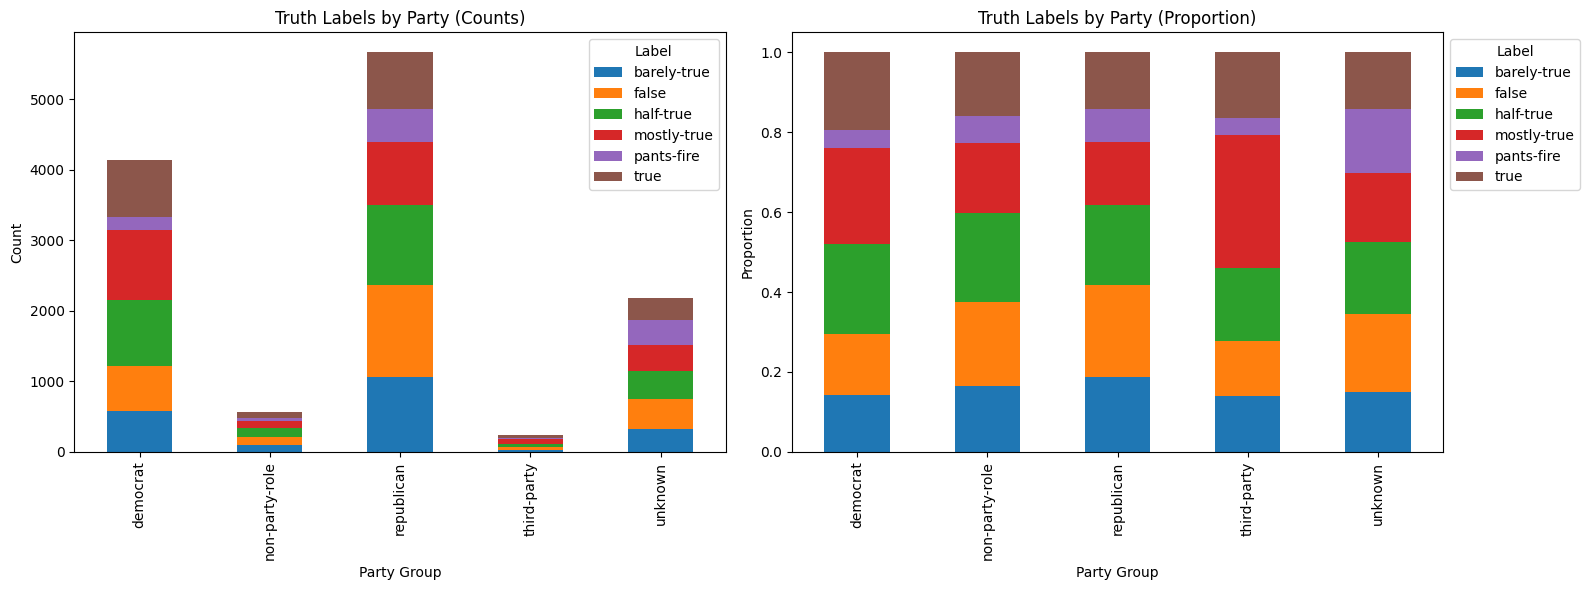

In [80]:
ct_counts = pd.crosstab(df["party_grouped"], df["label"])
ct_norm = pd.crosstab(df["party_grouped"], df["label"], normalize="index")

fig, axes = plt.subplots(1, 2, figsize=(16,6))

ct_counts.plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title("Truth Labels by Party (Counts)")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Party Group")
axes[0].legend(title="Label")

ct_norm.plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("Truth Labels by Party (Proportion)")
axes[1].set_ylabel("Proportion")
axes[1].set_xlabel("Party Group")
axes[1].legend(title="Label", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

The distribution of truth labels differs across party groups. Republican speakers exhibit a higher proportion of "false" and "pants-fire" ratings relative to Democrats, while Democrats show higher proportions of "mostly-true" and "true" statements. The "unknown" group displays a more even but slightly elevated extreme-rating distribution. These differences indicate that party affiliation correlates with fact-check outcomes, though class imbalance and speaker effects should be considered.

In [27]:
major = df[df["party_grouped"].isin(["democrat","republican"])]

print("Counts:")
print(major["party_grouped"].value_counts())

print("\nNormalized truth distribution by party:")
print(pd.crosstab(
    major["party_grouped"],
    major["label"],
    normalize="index"
))


Counts:
party_grouped
republican    5665
democrat      4138
Name: count, dtype: int64

Normalized truth distribution by party:
label          barely-true     false  half-true  mostly-true  pants-fire  \
party_grouped                                                              
democrat          0.141614  0.152972    0.22523     0.240454    0.044708   
republican        0.187290  0.229303    0.20000     0.159400    0.081377   

label              true  
party_grouped            
democrat       0.195022  
republican     0.142630  


<Figure size 800x600 with 0 Axes>

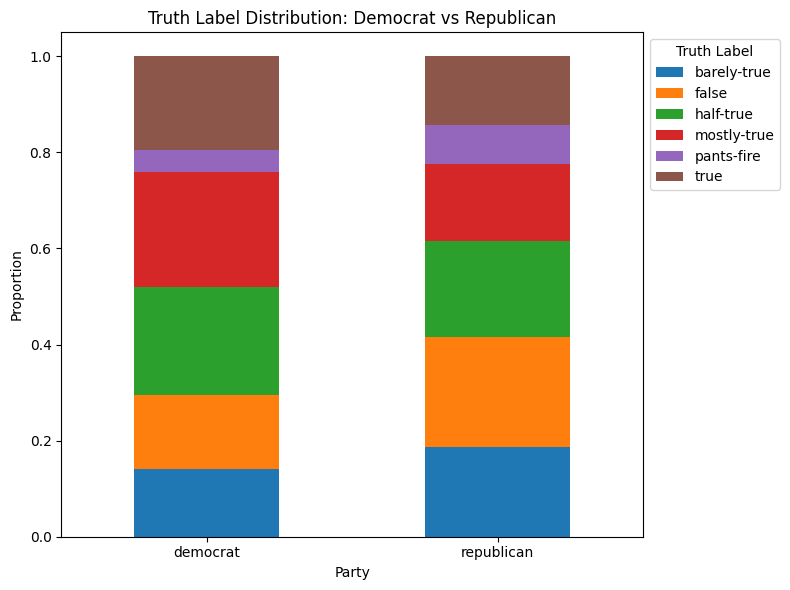

In [79]:
ct_major = pd.crosstab(
    major["party_grouped"],
    major["label"],
    normalize="index"
)

plt.figure(figsize=(8,6))

ct_major.plot(
    kind="bar",
    stacked=True,
    figsize=(8,6)
)

plt.title("Truth Label Distribution: Democrat vs Republican")
plt.ylabel("Proportion")
plt.xlabel("Party")
plt.xticks(rotation=0)
plt.legend(title="Truth Label", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

The distribution of truth labels differs across party groups. Republican speakers exhibit a higher proportion of "false" and "pants-fire" ratings relative to Democrats, while Democrats show higher proportions of "mostly-true" and "true" statements. The "unknown" group displays a more even but slightly elevated extreme-rating distribution. These differences indicate that party affiliation correlates with fact-check outcomes, though class imbalance and speaker effects should be considered.

# Statement Length Analysis

To explore whether linguistic surface features correlate with truthfulness, I analyze the distribution of statement length across truth labels. Statement length may reflect rhetorical style, complexity, or contextual framing, which could influence classification models.

In [28]:
df["statement_length"] = df["statement"].astype(str).str.len()

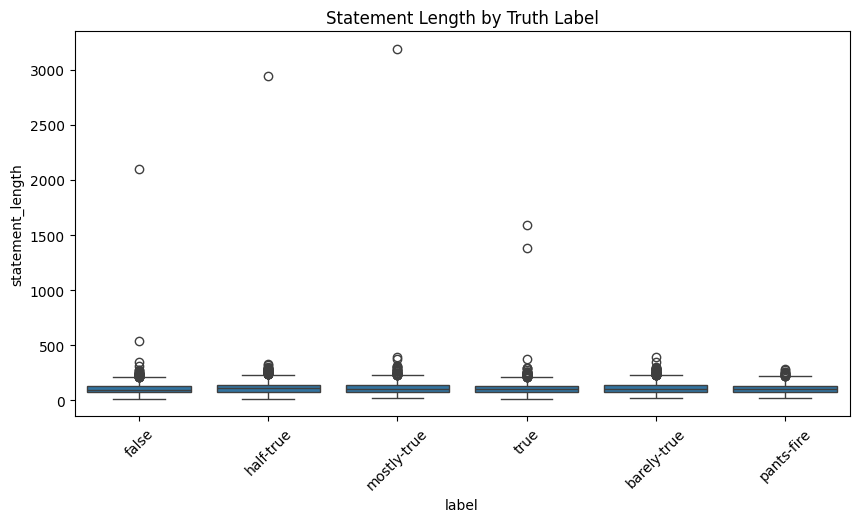

In [29]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="label", y="statement_length")
plt.xticks(rotation=45)
plt.title("Statement Length by Truth Label")
plt.show()

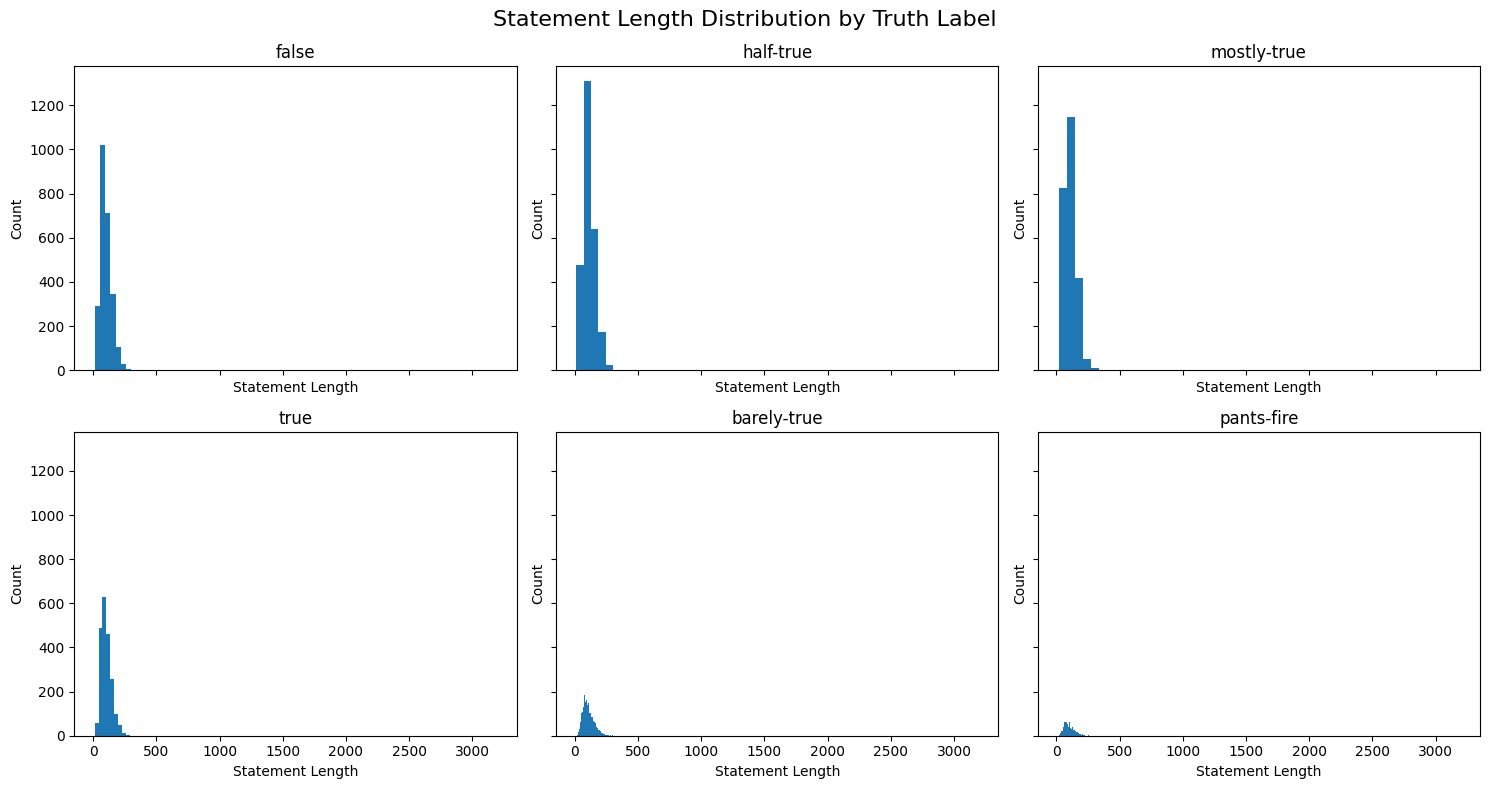

              count        mean        std   min   25%    50%     75%     max
label                                                                        
barely-true  2103.0  108.327627  46.021792  20.0  75.0  100.0  135.00   391.0
false        2507.0  100.911049  59.929239  11.0  69.0   92.0  126.00  2099.0
half-true    2627.0  112.737724  72.512846  11.0  77.0  105.0  139.00  2941.0
mostly-true  2454.0  109.178484  76.760415  19.0  74.0  100.0  134.75  3192.0
pants-fire   1047.0  102.942693  43.012122  16.0  70.0   96.0  129.50   278.0
true         2053.0  106.205066  60.989792  11.0  73.0   98.0  129.00  1592.0


In [49]:
labels = df["label"].unique()

fig, axes = plt.subplots(2, 3, figsize=(15,8), sharex=True, sharey=True)

axes = axes.flatten()

for i, lbl in enumerate(labels):
    subset = df[df["label"] == lbl]["statement_length"]
    
    axes[i].hist(subset, bins=50)
    axes[i].set_title(lbl)
    axes[i].set_xlabel("Statement Length")
    axes[i].set_ylabel("Count")

plt.suptitle("Statement Length Distribution by Truth Label", fontsize=16)
plt.tight_layout()
plt.show()

print(df.groupby("label")["statement_length"].describe())

I analyzed statement length across truth labels to evaluate whether superficial textual features correlate with fact-check outcomes. All categories exhibit strongly right-skewed distributions, with most statements falling roughly between 60 and 150 words.

Mean statement length is highly consistent across labels (approximately 100–113 words), indicating minimal structural difference between truth categories. Although extreme outliers appear in the “false,” “half-true,” and “mostly-true” groups, substantially increasing variance, these appear to be rare long-form statements rather than systematic differences.

Overall, statement length alone does not meaningfully differentiate truth labels, suggesting that semantic content and contextual features are likely far more informative than simple length-based metrics.

## Prior Statement Analysis

To investigate whether historical speaker behavior correlates with current truth labels, I analyze prior fact-check counts associated with each speaker. This allows assessment of potential reputation effects and whether speaker history may act as a predictive signal.

In [30]:
count_cols = [
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts"
]

df[count_cols] = df[count_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
df["total_prior_statements"] = df[count_cols].sum(axis=1)

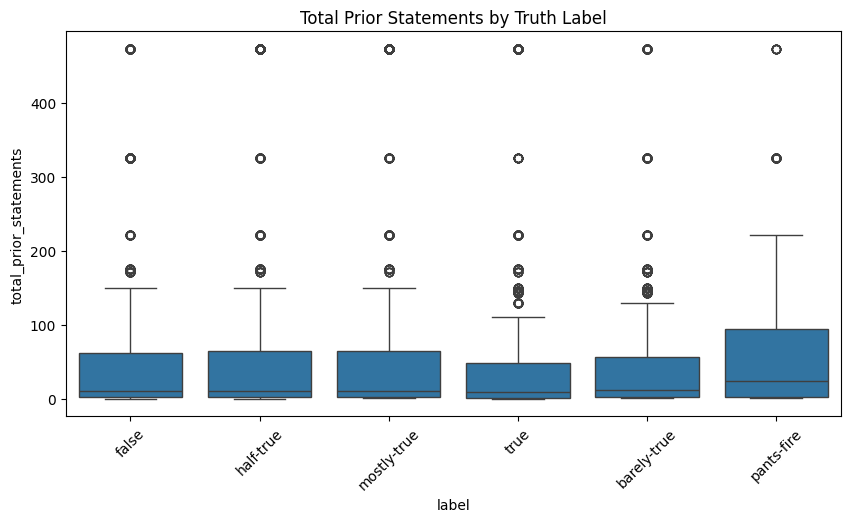

In [31]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="label", y="total_prior_statements")
plt.xticks(rotation=45)
plt.title("Total Prior Statements by Truth Label")
plt.show()

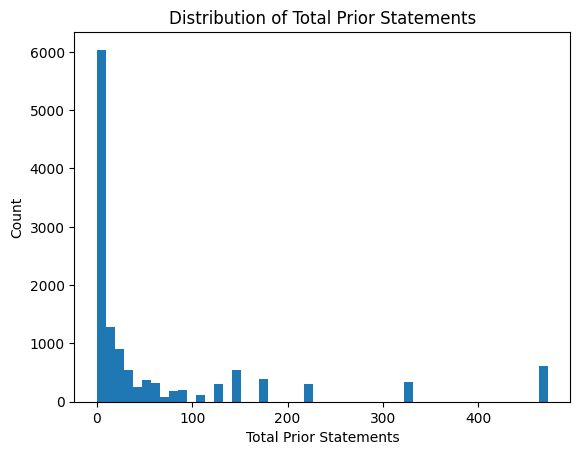

count    12791.000000
mean        64.867876
std        115.749162
min          0.000000
25%          2.000000
50%         11.000000
75%         65.000000
max        473.000000
Name: total_prior_statements, dtype: float64


In [40]:
plt.hist(df["total_prior_statements"], bins=50)
plt.title("Distribution of Total Prior Statements")
plt.xlabel("Total Prior Statements")
plt.ylabel("Count")
plt.show()

print(df["total_prior_statements"].describe())

I analyzed the distribution of total prior statements per speaker to understand whether speaker frequency may influence label patterns. The distribution is heavily right-skewed, indicating that a small number of speakers account for a large portion of the dataset. This suggests potential speaker concentration effects that could bias modeling results if not handled carefully.

Although the interquartile ranges overlap substantially across truth labels, statements rated “pants-fire” show a slightly higher median and wider upper range of prior statements compared to other categories. This indicates that highly frequent speakers may accumulate more extreme fact-check outcomes over time.

This pattern highlights a modeling concern: if a supervised classifier is trained without controlling for speaker identity or speaker frequency, it may partially learn speaker-specific tendencies rather than purely linguistic signals, introducing memorization risk.

# Statement Subject Analysis

To understand topical patterns in the dataset, I analyze the distribution of statement subjects. Since subject categories may influence truth ratings, examining their frequency and relationship to labels helps identify domain-specific trends and potential bias.

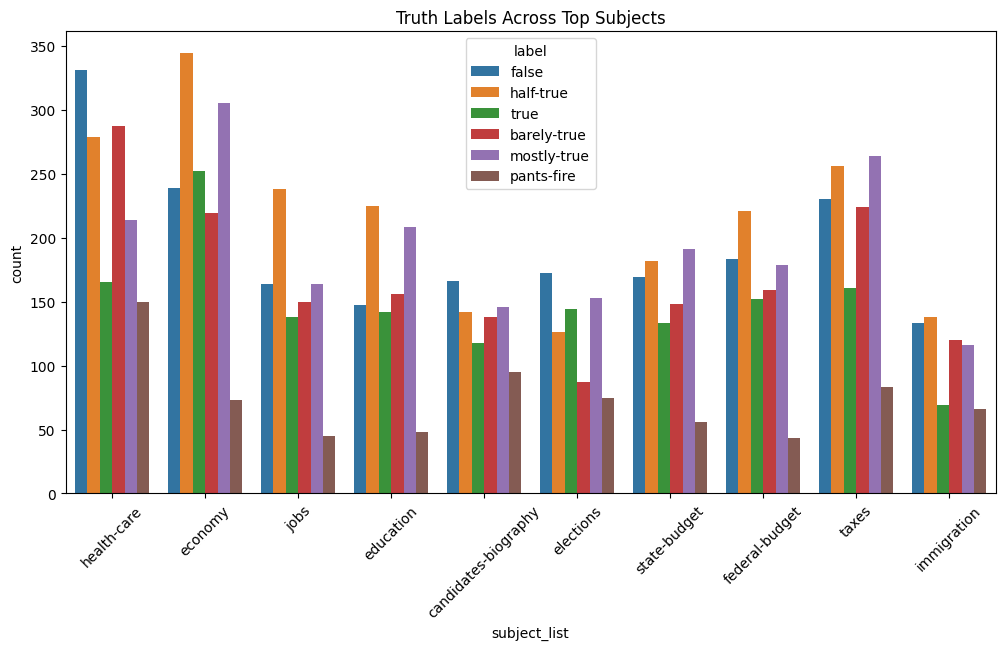

In [32]:
df["subject_list"] = df["subject"].str.split(",")

df_exploded = df.explode("subject_list")

df_exploded["subject_list"] = df_exploded["subject_list"].str.strip()

top_subjects = df_exploded["subject_list"].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.countplot(
    data=df_exploded[df_exploded["subject_list"].isin(top_subjects)],
    x="subject_list",
    hue="label"
)
plt.xticks(rotation=45)
plt.title("Truth Labels Across Top Subjects")
plt.show()

Since statements may belong to multiple subjects, I exploded the subject column into individual topic entries. This enables analysis of truth label distribution by topic. Results show topic-dependent variation in truth categories, suggesting that misinformation patterns may differ across policy domains.

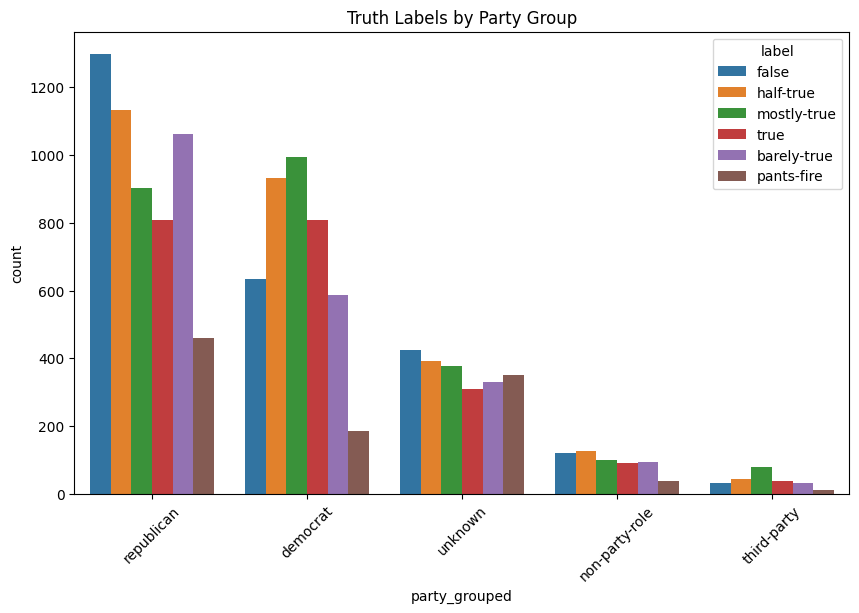

In [33]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="party_grouped", hue="label")
plt.xticks(rotation=45)
plt.title("Truth Labels by Party Group")
plt.show()

I examined the distribution of truth labels across grouped political affiliations to explore whether fact-check outcomes differ by party alignment. The dataset is dominated by Republican and Democrat speakers, with smaller representation from third-party, non-party roles, and unknown affiliations.

In absolute counts, Republican-affiliated speakers have more statements labeled “false” and “pants-fire,” while Democrat-affiliated speakers have relatively higher counts in the “mostly-true” and “true” categories. However, these differences should be interpreted cautiously because the total number of statements differs substantially across party groups.

This distribution suggests that party affiliation is correlated with label outcomes in the dataset. However, this correlation may reflect selection bias in the fact-checking process rather than  truthfulness differences. Fact-checking organizations may disproportionately evaluate high-profile or controversial claims, which could skew label distributions.

From a modeling perspective, party affiliation is likely to be a predictive feature. However, using it without careful consideration could introduce fairness concerns, as models may learn party-based patterns instead of purely linguistic signals.

# Speaker Reputation and Truth Label Correlation

To evaluate whether speaker history influences fact-check outcomes, I analyze how historical truth patterns correlate with current truth labels. This helps assess whether speaker reputation may act as a predictive signal in supervised models.

In [35]:
prior_cols = [
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "total_prior_statements"
]

print(df.groupby("label")[prior_cols].mean())

             barely_true_counts  false_counts  half_true_counts  \
label                                                             
barely-true           11.788873     12.481693         14.904422   
false                 11.313123     15.355006         14.595134   
half-true             12.265702     13.019794         20.483441   
mostly-true           11.969845     12.428280         19.840668   
pants-fire            10.765043     17.884432         11.152818   
true                  10.777399     11.046274         18.353142   

             mostly_true_counts  pants_on_fire_counts  total_prior_statements  
label                                                                          
barely-true           13.983833              5.353780               58.512601  
false                 13.438771              7.742321               62.444356  
half-true             19.106205              4.531024               69.406167  
mostly-true           20.687857              3.807253          

Historical fact-check patterns strongly correlate with current truth labels. Statements rated “pants-fire” are associated with speakers who have high prior pants-on-fire counts, while “mostly-true” and “true” statements come from speakers with stronger historical truth records. Similarly, “false” statements align with elevated prior false counts. This suggests that speaker reputation is predictive of current ratings, raising the possibility that supervised models may capture historical behavior signals rather than purely linguistic features.

# Top-20 Speaker Analysis

Given that a small number of speakers contribute a disproportionate share of statements, this section examines the truth-label distribution among the top 20 most frequent speakers. The goal is to assess whether speaker-specific patterns dominate the dataset.

In [37]:
top_speakers = df["speaker"].value_counts().head(20)

print(top_speakers)

print("\nProportion of dataset from top 20 speakers:")
print(top_speakers.sum() / len(df))

speaker
barack-obama       611
donald-trump       343
hillary-clinton    297
mitt-romney        212
john-mccain        189
scott-walker       183
chain-email        178
rick-perry         173
marco-rubio        153
rick-scott         150
ted-cruz           118
bernie-s           106
chris-christie     104
facebook-posts     100
charlie-crist       90
newt-gingrich       83
blog-posting        81
jeb-bush            79
joe-biden           76
paul-ryan           70
Name: count, dtype: int64

Proportion of dataset from top 20 speakers:
0.26549917911031196


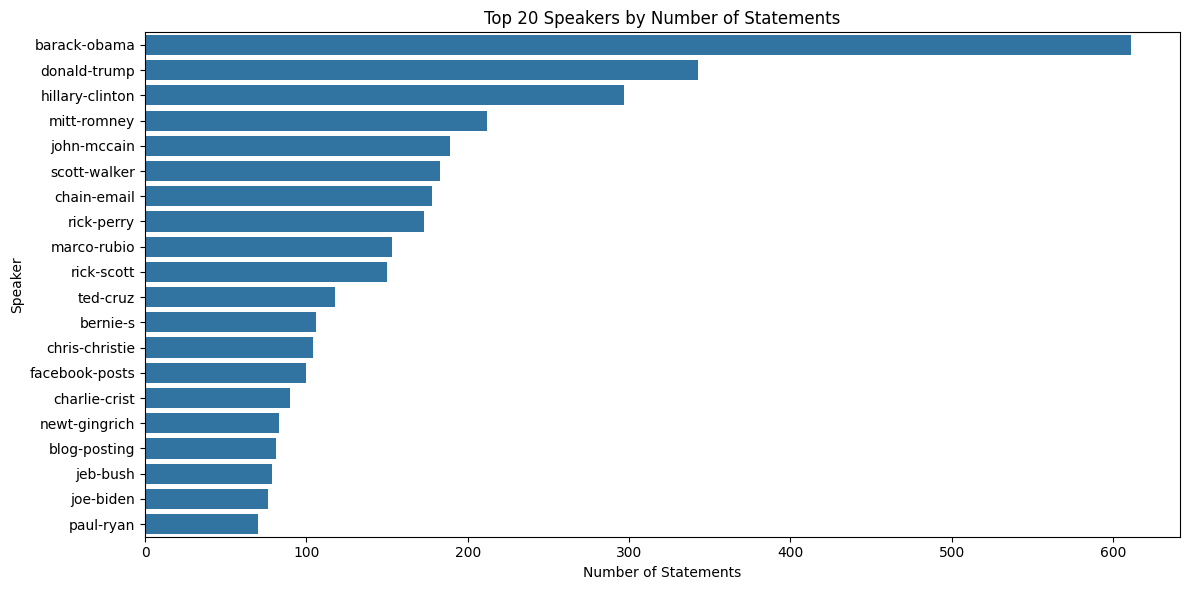

In [41]:
top_speakers = df["speaker"].value_counts().head(20)

plt.figure(figsize=(12,6))
sns.barplot(x=top_speakers.values, y=top_speakers.index)

plt.title("Top 20 Speakers by Number of Statements")
plt.xlabel("Number of Statements")
plt.ylabel("Speaker")
plt.tight_layout()
plt.show()

I examined speaker frequency to assess concentration effects. The top 20 speakers account for about 26.5% of all statements, meaning a small group contributes a large portion of the dataset.

This introduces potential speaker bias, models may learn speaker-specific patterns rather than purely linguistic signals of truthfulness.

In [38]:
top20 = df["speaker"].value_counts().head(20).index

top_df = df[df["speaker"].isin(top20)]

speaker_truth = pd.crosstab(
    top_df["speaker"],
    top_df["label"],
    normalize="index"
)

print(speaker_truth)

label            barely-true     false  half-true  mostly-true  pants-fire  \
speaker                                                                      
barack-obama        0.114566  0.132570   0.270049     0.266776    0.014730   
bernie-s            0.169811  0.113208   0.198113     0.386792    0.000000   
blog-posting        0.086420  0.234568   0.037037     0.061728    0.543210   
chain-email         0.061798  0.241573   0.044944     0.028090    0.589888   
charlie-crist       0.166667  0.166667   0.244444     0.222222    0.022222   
chris-christie      0.096154  0.173077   0.259615     0.182692    0.076923   
donald-trump        0.183673  0.341108   0.148688     0.107872    0.177843   
facebook-posts      0.140000  0.180000   0.150000     0.110000    0.360000   
hillary-clinton     0.134680  0.107744   0.232323     0.255892    0.023569   
jeb-bush            0.215190  0.063291   0.215190     0.303797    0.025316   
joe-biden           0.144737  0.144737   0.276316     0.210526  

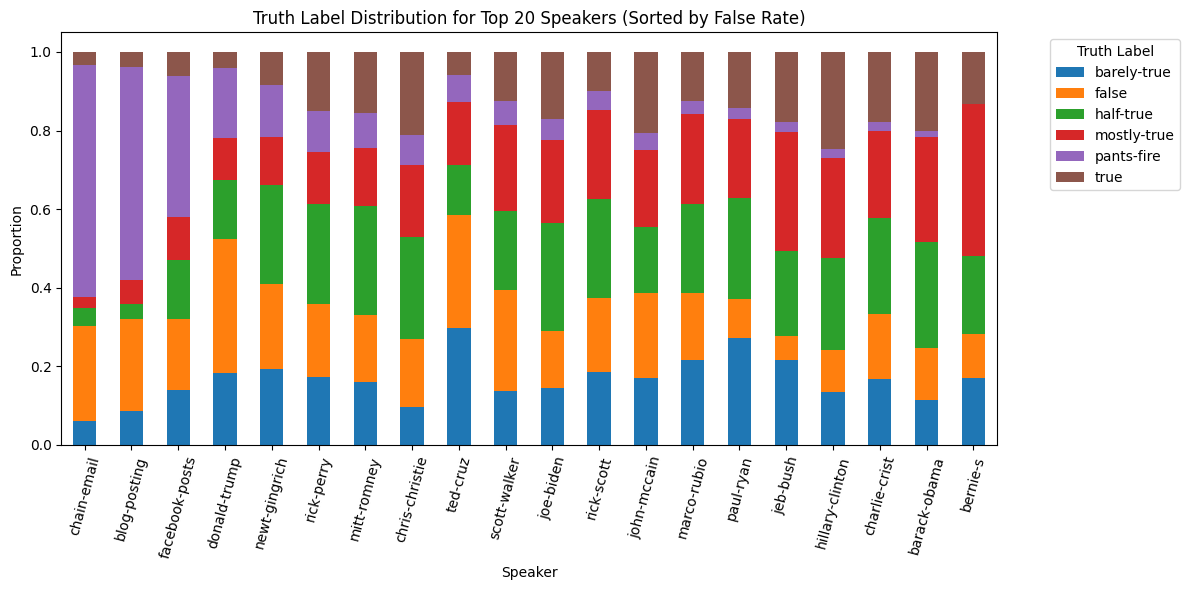

In [45]:
speaker_truth_sorted = speaker_truth.sort_values(by="pants-fire", ascending=False)

speaker_truth_sorted.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Truth Label Distribution for Top 20 Speakers (Sorted by False Rate)")
plt.xlabel("Speaker")
plt.ylabel("Proportion")
plt.legend(title="Truth Label", bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


I analyzed truth label proportions across the top 20 speakers to understand speaker-level variation in fact-check outcomes. The distributions differ substantially: for example, “chain-email” and “blog-posting” show very high proportions of pants-fire, while figures like Barack Obama and Hillary Clinton have higher proportions of half-true and mostly-true. Donald Trump shows a comparatively high proportion of false ratings.

These differences reinforce the presence of strong speaker effects in the dataset. Truth labels are not evenly distributed across speakers, which suggests that models trained without speaker-aware splitting may unintentionally learn speaker identity patterns rather than general linguistic indicators of truthfulness.

In [83]:
df.to_csv("../data/processed/processed_liar.csv")

# Summary

* Label distribution is moderately balanced (no extreme imbalance)

* Speaker concentration is high (top 20 = 26.5%)

* Party alignment correlates with truth distribution

* Prior statement history shows behavioral consistency patterns

* Length provides little discriminative power

# Source Declaration

1. AI Tools:
* ChatGPT: Helped idealize what a good EDA would look like for the chosen dataset.
* ChatGPT: Assisted in debuging code, creating plots, and professionalizing the language used in the analysis.

2. Dataset:
* Wang, William. ‘”Liar, Liar Pants on Fire”: A New Benchmark Dataset for Fake News detection”. ArXiv. https://doi.org/10.48550/arXiv.1705.00648